In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import chi2, SelectKBest

In [ ]:
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data', header=None)
data.columns = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
                'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
                'Normal Nucleoli', 'Mitoses','Class']


In [ ]:
data.shape

(699, 11)

In [ ]:

data1=data.drop( 'Sample code',axis=1)

In [ ]:
data1.shape

(699, 10)

In [ ]:
print(data1.shape)
print('------------------------')
print(data1.head())
print('------------------------')
print(data1.info())
print('------------------------')
print(data1.describe())

(699, 10)
------------------------
   Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
0                5                        1                         1   
1                5                        4                         4   
2                3                        1                         1   
3                6                        8                         8   
4                4                        1                         1   

   Marginal Adhesion  Single Epithelial Cell Size Bare Nuclei  \
0                  1                            2           1   
1                  5                            7          10   
2                  1                            2           2   
3                  1                            3           4   
4                  3                            2           1   

   Bland Chromatin  Normal Nucleoli  Mitoses  Class  
0                3                1        1      2  
1                3         

In [ ]:
#To set 'nan' string in the missing value
data1 = data1.replace('?',np.nan)
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Clump Thickness              699 non-null    int64 
 1   Uniformity of Cell Size      699 non-null    int64 
 2   Uniformity of Cell Shape     699 non-null    int64 
 3   Marginal Adhesion            699 non-null    int64 
 4   Single Epithelial Cell Size  699 non-null    int64 
 5   Bare Nuclei                  683 non-null    object
 6   Bland Chromatin              699 non-null    int64 
 7   Normal Nucleoli              699 non-null    int64 
 8   Mitoses                      699 non-null    int64 
 9   Class                        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [ ]:
#Find the number of each columns missing values
for col in data1.columns:
 print(f"{col} = {data1[col].isnull().sum()}")


Clump Thickness = 0
Uniformity of Cell Size = 0
Uniformity of Cell Shape = 0
Marginal Adhesion = 0
Single Epithelial Cell Size = 0
Bare Nuclei = 16
Bland Chromatin = 0
Normal Nucleoli = 0
Mitoses = 0
Class = 0


In [ ]:
data2=data1['Bare Nuclei']
print('Before replacing missing values:')
print(data2[20:25])
data4 = pd.to_numeric(data2)

# Replace missing values with median
data4=data4.fillna(data4.median())

print('\nAfter replacing missing values:')
print(data4[20:25])
data['Bare Nuclei']=data4


Before replacing missing values:
20     10
21      7
22      1
23    NaN
24      1
Name: Bare Nuclei, dtype: object

After replacing missing values:
20    10.0
21     7.0
22     1.0
23     1.0
24     1.0
Name: Bare Nuclei, dtype: float64


In [ ]:
print(f"Number of rows in original data = {data1.shape[0]}")
data2.dropna()

Number of rows in original data = 699


,Bare Nuclei
0,1
1,10
2,2
3,4
4,1
...,...
694,2
695,1
696,3
697,4


In [ ]:
data1.describe().head()


,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000


<Axes: >

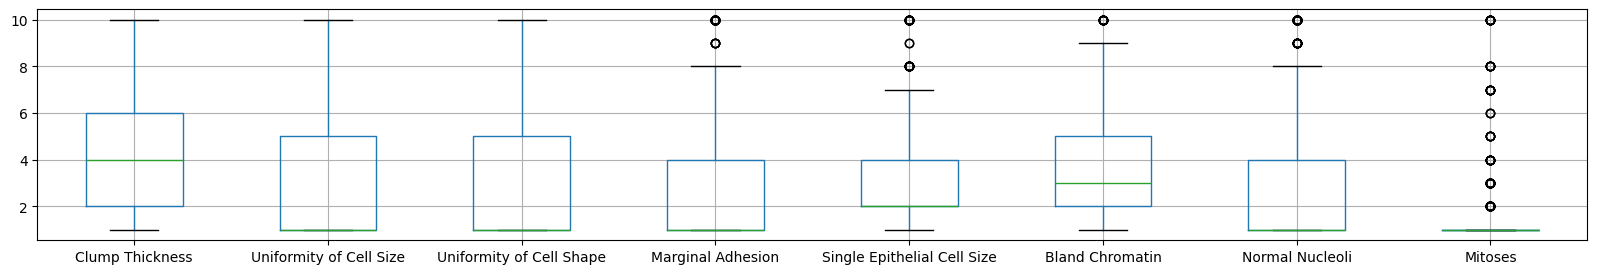

In [ ]:

%matplotlib inline

if 'Class' in data1.columns:
    data77 = data1.drop(['Class'],axis=1)
else:
    data77 = data1.copy()
data1.boxplot(figsize=(20,3))

In [ ]:
Z = (data1-data1.mean())/data1.std()
Z[222:250]

,Bare Nuclei
222,0.417896
223,1.246184
224,1.798376
225,-0.686488
226,1.798376
227,0.417896
228,-0.686488
229,1.798376
230,0.970088
231,1.246184


<Axes: >

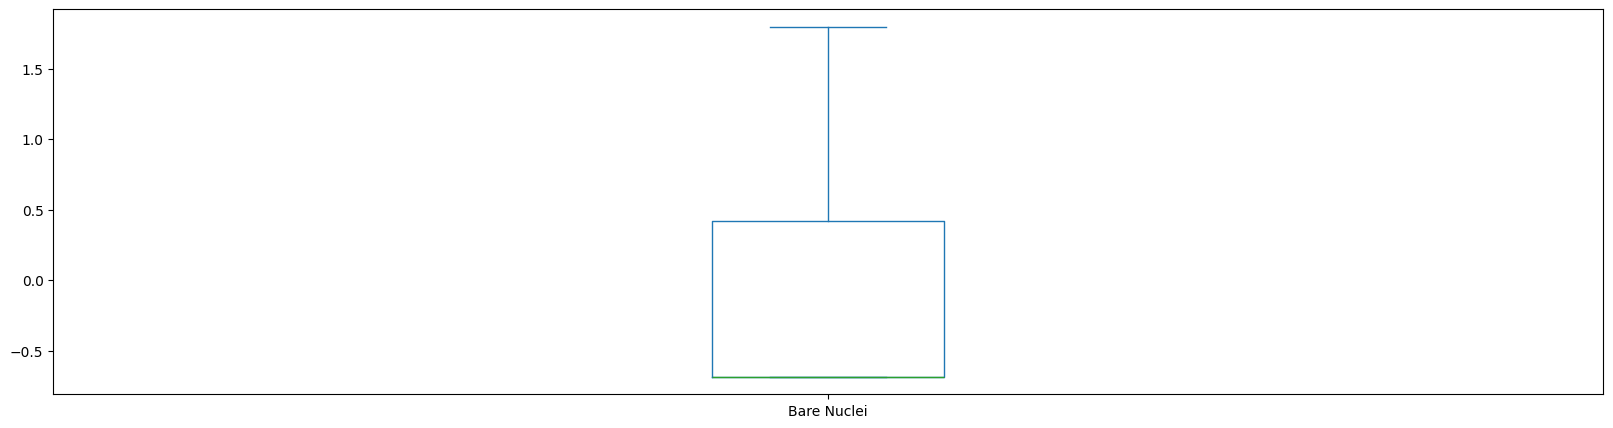

In [ ]:
Z.plot.box(figsize=(20,5))

In [ ]:
print('Number of rows before discarding outliers = %d' % (Z.shape[0]))

Z2 = Z[(Z > -3) & (Z <= 3)]
print('Number of rows after discarding outliers = %d' % (Z2.shape[0]))

Number of rows before discarding outliers = 699
Number of rows after discarding outliers = 699


In [ ]:
dups = data.duplicated()
print(f'Number of duplicate rows = {dups.sum()}')
data.loc[[11,28]]

Number of duplicate rows = 9


,Sample code,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
11,1036172,2,1,1,1,2,1.0,2,1,1
28,1067444,2,1,1,1,2,1.0,2,1,1


In [ ]:
dups = data.duplicated()
print(f'Number of duplicate rows = {dups.sum()}')
data.loc[[11,28]]

Number of duplicate rows = 9


,Sample code,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
11,1036172,2,1,1,1,2,1.0,2,1,1,2
28,1067444,2,1,1,1,2,1.0,2,1,1,2


In [ ]:

data2 = data.drop_duplicates()
print(f'Number of rows after discarding duplicates ={(data2.shape[0])}')

Number of rows before discarding duplicates = 699
Number of rows after discarding duplicates =690


In [ ]:
#PCA(PRINCIPLE COMPONENT ANALYSIS)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
#Step;01:Create dataset
data={
    'Height':[160,165,170,175,180],
    'Weight':[60,65,70,75,80],
    'Age':[25,30,35,40,45]
}
df=pd.DataFrame(data)
df


,Height,Weight,Age
0,160,60,25
1,165,65,30
2,170,70,35
3,175,75,40
4,180,80,45


In [ ]:
#step:02:standarized data
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)
scaled_data

array([[-1.41421356, -1.41421356, -1.41421356],
       [-0.70710678, -0.70710678, -0.70710678],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.70710678,  0.70710678,  0.70710678],
       [ 1.41421356,  1.41421356,  1.41421356]])

In [ ]:
#Step:03:PCA
pca=PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_result

array([[-2.44948974e+00,  3.43990023e-16],
       [-1.22474487e+00, -1.14663341e-16],
       [ 0.00000000e+00, -0.00000000e+00],
       [ 1.22474487e+00,  1.14663341e-16],
       [ 2.44948974e+00,  2.29326682e-16]])

In [ ]:
#step:04:Convert result to data frame
pca_df=pd.DataFrame(
    data=pca_result,
    columns=['PCA 1','PCA 2']
)
pca_df

,PCA 1,PCA 2
0,-2.449490,3.439900e-16
1,-1.224745,-1.146633e-16
2,0.000000,-0.000000e+00
3,1.224745,1.146633e-16
4,2.449490,2.293267e-16


In [ ]:
#Step:05:print output
print("Original Data:")
print(df)
print("\nStandardized Data:")
print(scaled_data)
print("\nPCA Result:")
print(pca_df)

Original Data:
   Height  Weight  Age
0     160      60   25
1     165      65   30
2     170      70   35
3     175      75   40
4     180      80   45

Standardized Data:
[[-1.41421356 -1.41421356 -1.41421356]
 [-0.70710678 -0.70710678 -0.70710678]
 [ 0.          0.          0.        ]
 [ 0.70710678  0.70710678  0.70710678]
 [ 1.41421356  1.41421356  1.41421356]]

PCA Result:
      PCA 1         PCA 2
0 -2.449490  3.439900e-16
1 -1.224745 -1.146633e-16
2  0.000000 -0.000000e+00
3  1.224745  1.146633e-16
4  2.449490  2.293267e-16


In [ ]:
#Descretization..............
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Sample continuous data
data = {
    'Marks': [35, 40, 45, 50, 55, 60, 70, 80, 90]
}
df = pd.DataFrame(data)

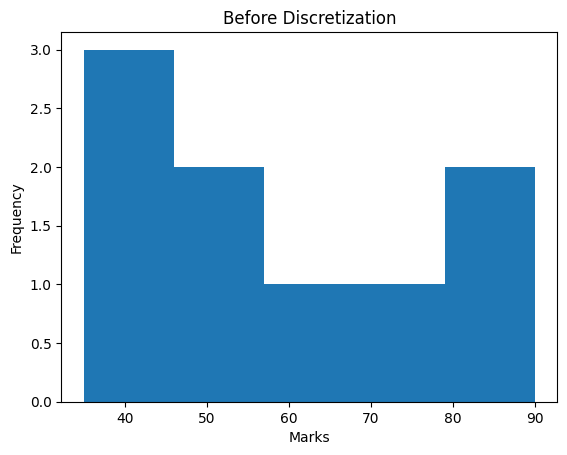

In [ ]:
plt.figure()
plt.hist(df['Marks'], bins=5)
plt.title("Before Discretization")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

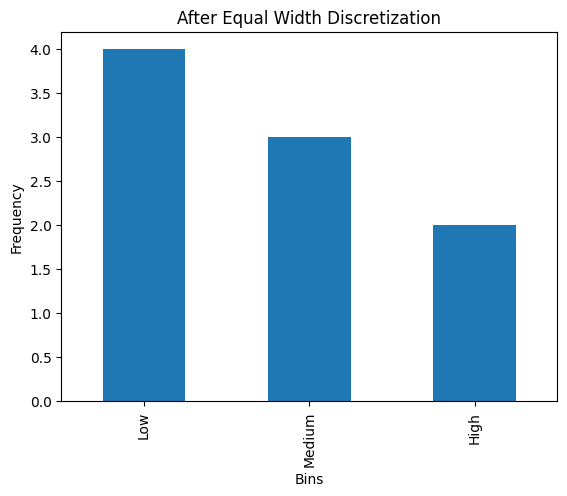

In [ ]:
df['Equal_Width'] = pd.cut(
    df['Marks'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)
plt.figure()
df['Equal_Width'].value_counts().sort_index().plot(kind='bar')
plt.title("After Equal Width Discretization")
plt.xlabel("Bins")
plt.ylabel("Frequency")
plt.show()

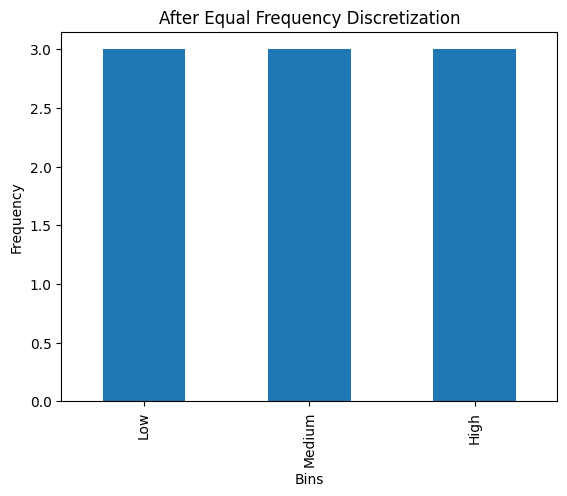

   Marks Equal_Width Equal_Frequency
0     35         Low             Low
1     40         Low             Low
2     45         Low             Low
3     50         Low          Medium
4     55      Medium          Medium
5     60      Medium          Medium
6     70      Medium            High
7     80        High            High
8     90        High            High


In [ ]:
df['Equal_Frequency'] = pd.qcut(
    df['Marks'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
plt.figure()
df['Equal_Frequency'].value_counts().sort_index().plot(kind='bar')
plt.title("After Equal Frequency Discretization")
plt.xlabel("Bins")
plt.ylabel("Frequency")
plt.show()



print(df)

In [ ]:
#AGGREGATION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Weatherset/weather.csv')
print(df)

Mounted at /content/drive
            date  precipitation  temp_max  temp_min  wind  weather
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle
1     2012-01-02           10.9      10.6       2.8   4.5     rain
2     2012-01-03            0.8      11.7       7.2   2.3     rain
3     2012-01-04           20.3      12.2       5.6   4.7     rain
4     2012-01-05            1.3       8.9       2.8   6.1     rain
...          ...            ...       ...       ...   ...      ...
1456  2015-12-27            8.6       4.4       1.7   2.9     rain
1457  2015-12-28            1.5       5.0       1.7   1.3     rain
1458  2015-12-29            0.0       7.2       0.6   2.6      fog
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun

[1461 rows x 6 columns]


Daily Precipitation Data:


Text(0.5, 1.0, 'Daily Precipitation (variance = 44.6250)')

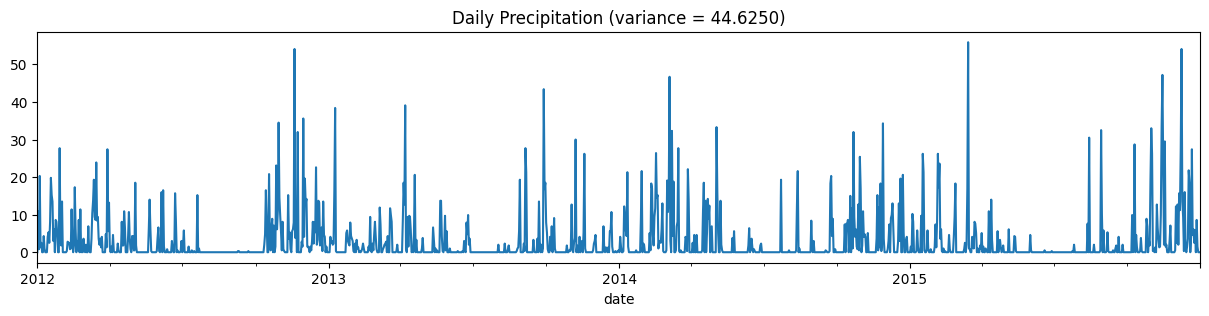

In [ ]:
daily = df.copy()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.set_index('date')['precipitation']

print("Daily Precipitation Data:")
#print(data)
ax = daily.plot(kind='line',figsize=(15,3))
ax.set_title('Daily Precipitation (variance = %.4f)' % (daily.var()))

/tmp/ipython-input-2107550002.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.groupby(pd.Grouper(freq='M')).sum()


Text(0.5, 1.0, 'Monthly Precipitation (variance = 4872.2570)')

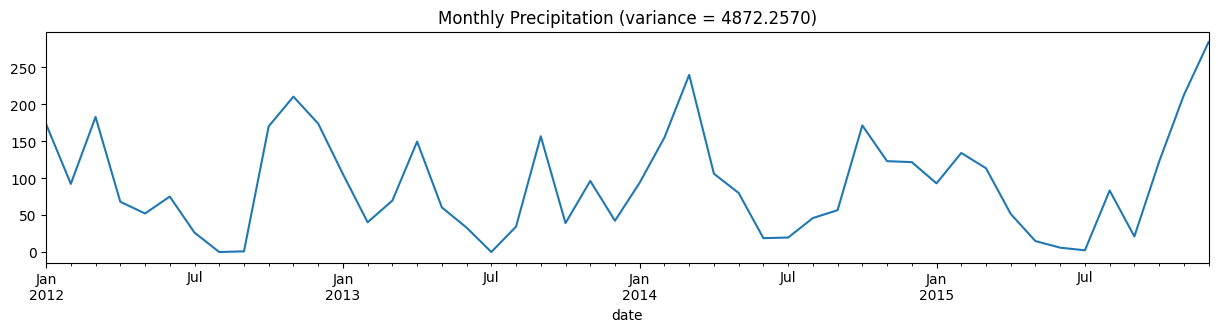

In [ ]:
monthly = daily.groupby(pd.Grouper(freq='M')).sum()
ax = monthly.plot(kind='line',figsize=(15,3))
ax.set_title('Monthly Precipitation (variance = %.4f)' % (monthly.var()))

/tmp/ipython-input-2798781123.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = daily.groupby(pd.Grouper(freq='Y')).sum()


Text(0.5, 1.0, 'Annual Precipitation (variance = 36287.8267)')

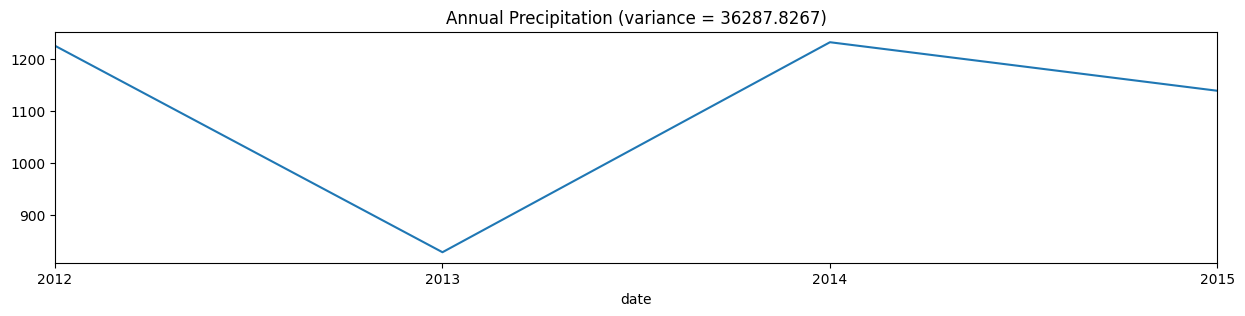

In [ ]:
annual = daily.groupby(pd.Grouper(freq='Y')).sum()
ax = annual.plot(kind='line',figsize=(15,3))
ax.set_title('Annual Precipitation (variance = %.4f)' % (annual.var()))

In [ ]:
#SAMPLING.......

In [ ]:
#Simple random Sampling

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Sampling/behavior.csv')
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      Customer_Click_Binary  Product_Sales_Count  Attempts_Till_Success  \
0                         0                   10                     10   
1                         0                   12                      3   
2                         0                    9                      1   
3                         0                   12                      7   
4                         1                   13                      1   
...                     ...                  ...                    ...   
9995                      1                   16                      3   
9996                      1                   10                      2   
9997                      0                   13                      3   
9998                      0                   13                      6   
9999                      1                   

In [ ]:
import random
N = len(df)# Population
print("Total Datasets populations:", N)
n = 100 # Sample Size

Total Datasets populations: 10000


In [ ]:
simple_random_sampling = df.sample(n = n,random_state = 42)

print("Type of the sample is :",type(simple_random_sampling))


Type of the sample is : <class 'pandas.core.frame.DataFrame'>


In [ ]:
print("Len of Simple Random Sampling:", len(simple_random_sampling))

Len of Simple Random Sampling: 100


In [ ]:
print(simple_random_sampling.index.tolist())

[6252, 4684, 1731, 4742, 4521, 6340, 576, 5202, 6363, 439, 2750, 7487, 5272, 5653, 3999, 6033, 582, 9930, 7051, 8158, 9896, 2249, 4640, 9485, 4947, 9920, 1963, 8243, 6590, 8847, 321, 2678, 4625, 4949, 8328, 3337, 5589, 251, 3973, 6630, 5547, 35, 8362, 1513, 9317, 39, 4819, 3465, 1760, 2304, 3723, 8284, 4993, 8127, 3032, 7938, 3039, 9655, 2545, 2592, 1188, 7966, 6077, 107, 1315, 8187, 2753, 9753, 6231, 2876, 5323, 799, 3570, 2894, 2927, 8178, 971, 6687, 8575, 2020, 9054, 952, 5359, 3857, 5861, 3145, 3305, 3006, 9001, 7770, 7438, 7942, 9238, 1056, 3154, 3787, 9189, 7825, 7539, 7231]


In [ ]:
import numpy as np
def sysSampling(datasets, n=100):
    N = len(datasets)
    k = N//n
    starting = np.random.randint(0, k)
    dataIndex = list(range(starting,starting+ k*n,  k))[:n]
    return datasets.iloc[dataIndex]

sysSampling(df)

,Customer_Click_Binary,Product_Sales_Count,Attempts_Till_Success,Calls_Per_Hour,Item_Rating,Download_Time,Temperature,Time_Until_Event,Insurance_Claims,Ad_Click_Probability,...,Retries_Before_Success,Waiting_Time,Transaction_Amount,Purchase_Probability,Content_Sharing_Rate,Temperature_Sensor2,Order_Shipping_Days,Rating_Consistency,Clicks_Per_Session,Visits_Until_Purchase
90,1,14,1,8,3,5.940083,37.393017,0.688668,1022.076035,0.340358,...,3,0.791312,432.460060,0.792148,0.362578,36.273181,5,0.974137,8,5
190,0,13,2,2,3,2.309241,35.448827,1.621666,903.095244,0.391058,...,13,0.635171,632.983567,0.600666,0.358286,36.732717,4,0.958608,10,18
290,0,11,1,10,2,2.878384,36.833658,2.110189,3178.435241,0.616148,...,1,1.554123,955.378561,0.932623,0.582880,36.737565,4,0.951489,9,23
390,1,14,2,8,5,2.987266,36.848726,4.990158,1823.430001,0.261223,...,14,1.523856,1107.624421,0.616297,0.293422,36.656887,8,0.936616,9,13
490,1,13,4,2,5,3.353506,36.774846,2.398457,3501.547288,0.083468,...,14,0.691133,657.033991,0.535094,0.369855,37.139266,3,0.433722,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9590,1,15,9,2,4,8.918614,36.785251,0.017732,1663.639388,0.143554,...,1,2.235340,434.113608,0.837112,0.598714,36.926174,1,0.134975,7,7
9690,1,13,3,0,5,7.295537,36.637463,1.680553,986.063543,0.459768,...,18,3.547308,797.651521,0.935456,0.681755,36.585687,3,0.859752,10,13
9790,0,12,17,3,5,9.615804,38.104863,0.238150,834.008475,0.233221,...,2,0.424941,460.280006,0.791812,0.792594,36.094687,3,0.819212,11,13
9890,0,13,8,4,4,5.927267,36.634435,0.912547,753.120028,0.261043,...,1,0.954513,746.271877,0.944952,0.855611,36.317788,4,0.744595,6,5


In [ ]:
#Simple random Sampling

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Age/age_gender1.csv')
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       age  ethnicity  gender                        img_name  \
0        1          2       0  20161219203650636.jpg.chip.jpg   
1        1          2       0  20161219222752047.jpg.chip.jpg   
2        1          2       0  20161219222832191.jpg.chip.jpg   
3        1          2       0  20161220144911423.jpg.chip.jpg   
4        1          2       0  20161220144914327.jpg.chip.jpg   
...    ...        ...     ...                             ...   
23700   99          0       1  20170120221920654.jpg.chip.jpg   
23701   99          1       1  20170120134639935.jpg.chip.jpg   
23702   99          2       1  20170110182418864.jpg.chip.jpg   
23703   99          2       1  20170117195405372.jpg.chip.jpg   
23704   99          0       1  20170110182052119.jpg.chip.jpg   

                                                  pixels  
0      129 128 128 126 127 130 

In [ ]:
# Apriori Algorithm

In [1]:
from itertools import combinations

def apriori(transactions, min_support):
    itemset = set()
    for t in transactions:
        for item in t:
            itemset.add(frozenset([item]))

    def get_support(itemsets):
        support_count = {}
        for item in itemsets:
            count = 0
            for t in transactions:
                if item.issubset(t):
                    count += 1
            support_count[item] = count / len(transactions)
        return support_count

    L = []
    C1 = get_support(itemset)
    L1 = {item: sup for item, sup in C1.items() if sup >= min_support}
    L.append(L1)

    k = 2
    while True:
        prev_L = list(L[-1].keys())
        candidates = set(
            frozenset(i.union(j))
            for i in prev_L
            for j in prev_L
            if len(i.union(j)) == k
        )

        Ck = get_support(candidates)
        Lk = {item: sup for item, sup in Ck.items() if sup >= min_support}

        if not Lk:
            break

        L.append(Lk)
        k += 1

    return L


In [2]:
transactions = [
    {'A','B','C'},
    {'A','C'},
    {'A','D'},
    {'B','C'},
    {'A','B','C','D'}
]

frequent_itemsets = apriori(transactions, min_support=0.4)

for level in frequent_itemsets:
    print(level)


{frozenset({'D'}): 0.4, frozenset({'B'}): 0.6, frozenset({'C'}): 0.8, frozenset({'A'}): 0.8}
{frozenset({'B', 'C'}): 0.6, frozenset({'A', 'D'}): 0.4, frozenset({'A', 'B'}): 0.4, frozenset({'A', 'C'}): 0.6}
{frozenset({'A', 'B', 'C'}): 0.4}


In [ ]:
# FP Growth Algorithm

In [3]:
class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None

def build_fp_tree(transactions, min_support):
    from collections import defaultdict

    item_count = defaultdict(int)
    for t in transactions:
        for item in t:
            item_count[item] += 1

    item_count = {
        item: count
        for item, count in item_count.items()
        if count >= min_support
    }

    if len(item_count) == 0:
        return None, None

    header_table = {item: None for item in item_count}

    root = FPNode(None, 1, None)

    for t in transactions:
        ordered_items = [
            item for item in sorted(
                t, key=lambda x: item_count.get(x, 0), reverse=True
            ) if item in item_count
        ]

        current = root
        for item in ordered_items:
            if item in current.children:
                current.children[item].count += 1
            else:
                new_node = FPNode(item, 1, current)
                current.children[item] = new_node

                if header_table[item] is None:
                    header_table[item] = new_node
                else:
                    temp = header_table[item]
                    while temp.link:
                        temp = temp.link
                    temp.link = new_node

            current = current.children[item]

    return root, header_table


In [4]:
transactions = [
    ['A','B','C'],
    ['A','C'],
    ['A','D'],
    ['B','C'],
    ['A','B','C','D']
]

min_support_count = 2

root, header = build_fp_tree(transactions, min_support_count)

print("FP-Tree built successfully!")


FP-Tree built successfully!


In [ ]:
# Linear Regression and Logistic regression

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Sample dataset
data = {
    'experience': [1, 2, 3, 4, 5, 6, 7, 10],
    'salary': [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000]
}

df = pd.DataFrame(data)

# Features and target
X = df[['experience']]   # Independent variable
y = df['salary']         # Dependent variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Coefficients
print("Slope (m):", model.coef_)
print("Intercept (c):", model.intercept_)



MSE: 4444444.444444431
R2 Score: 0.9555555555555557
Slope (m): [4000.]
Intercept (c): 28333.33333333333


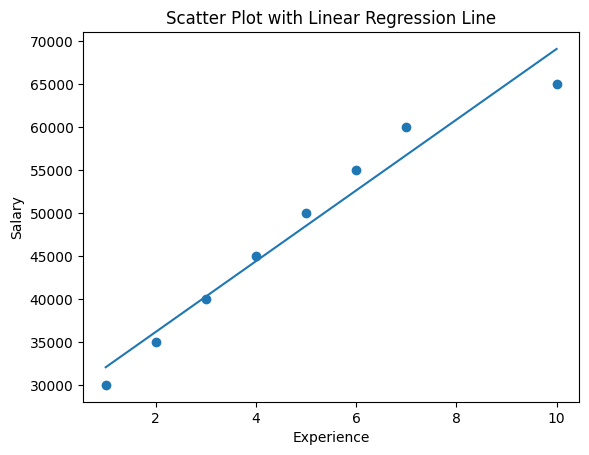

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data
X = np.array([1, 2, 3, 4, 5, 6, 7, 10]).reshape(-1, 1)
y = np.array([30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000])

# Linear Regression
model = LinearRegression()
model.fit(X, y)

# Prediction
y_pred = model.predict(X)

# Plot
plt.scatter(X, y)        # scatter dots
plt.plot(X, y_pred)     # regression line
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Scatter Plot with Linear Regression Line")
plt.show()


In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sample dataset
data = {
    'study_hours': [1, 2, 3, 4, 5, 6, 7, 8],
    'pass': [0, 0, 0, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Features and target
X = df[['study_hours']]
y = df['pass']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

